# Détection de langue avec réseaux de neurones récurrents (RNN)

Les réseaux de neurones récurrents (RNN) sont appropriés pour traiter des données séquentielles, où chaque point dépend du/des précédent(s). C'est le cas, par exemple, pour les séries temporelles (signaux audio/parole, données financières...), mais aussi les vidéos (séquence temporelle d'images), ou le texte, que nous considérons ici.
 
Dans ce lab, nous utilisons les RNN pour une tâche de classification multi-classe, qui est la détection de langue à partir de textes. Nous introduisons le pipeline global pour le prétraitement des données textuelles, ainsi que les bases des RNN, et nous implémentons un modèle de classification simple.

**Note**: Ce notebook utilise spaCy pour le traitement du langage naturel. Assurez-vous que les pipelines nécessaires sont installés.

In [1]:
# Décommenter si vous n'avez pas encore téléchargé les pipelines spacy
# import spacy.cli
# spacy.cli.download("en_core_web_sm")
# spacy.cli.download("fr_core_news_sm")

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
import copy
import matplotlib.pyplot as plt
import spacy
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from collections import Counter

In [3]:
# Chemin vers le dataset
data_path = "C:\\Users\\A1150064\\OneDrive - ArcelorMittal\\Bureau\\Détection_Langue\\dataset.csv"

### Dataset

Nous utilisons un dataset de détection de langue contenant 22,000 textes en 22 langues différentes (1000 échantillons par langue). Le dataset a deux colonnes :
- **Text** : le texte dans différentes langues
- **language** : la langue du texte

In [4]:
# Charger le dataset
df = pd.read_csv(data_path)
print(f"Taille du dataset: {len(df)}")
print(f"\nNombre de langues: {df['language'].nunique()}")
print(f"\nDistribution des langues:")
print(df['language'].value_counts())

# Afficher un exemple
print(f"\nExemple:")
print(df.iloc[0])

Taille du dataset: 22000

Nombre de langues: 22

Distribution des langues:
language
Estonian      1000
Swedish       1000
Thai          1000
Tamil         1000
Dutch         1000
Japanese      1000
Turkish       1000
Latin         1000
Urdu          1000
Indonesian    1000
Portugese     1000
French        1000
Chinese       1000
Korean        1000
Hindi         1000
Spanish       1000
Pushto        1000
Persian       1000
Romanian      1000
Russian       1000
English       1000
Arabic        1000
Name: count, dtype: int64

Exemple:
Text        klement gottwaldi surnukeha palsameeriti ning ...
language                                             Estonian
Name: 0, dtype: object


## Prétraitement des données textuelles

### Encodage des labels

Nous devons d'abord encoder les labels de langue (texte) en indices numériques.

In [7]:
# Encoder les labels de langue
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['language'])

# Créer un dictionnaire de mapping
label_to_lang = dict(enumerate(label_encoder.classes_))
lang_to_label = {v: k for k, v in label_to_lang.items()}

print("Mapping langue -> label:")
for lang, label in sorted(lang_to_label.items()):
    print(f"{lang}: {label}")
    
print(f"\nNombre de classes: {len(label_to_lang)}")

Mapping langue -> label:
Arabic: 0
Chinese: 1
Dutch: 2
English: 3
Estonian: 4
French: 5
Hindi: 6
Indonesian: 7
Japanese: 8
Korean: 9
Latin: 10
Persian: 11
Portugese: 12
Pushto: 13
Romanian: 14
Russian: 15
Spanish: 16
Swedish: 17
Tamil: 18
Thai: 19
Turkish: 20
Urdu: 21

Nombre de classes: 22


### Tokenizers

#### Pour transformer nos textes en séquences de tokens, nous utilisons un tokenizer basique au niveau des caractères. Cela est plus approprié pour la détection de langue car différentes langues utilisent différents alphabets et caractères.

In [8]:
# Tokenization au niveau des caractères
def tokenize_text(text, max_len=200):
    """Tokenize au niveau des caractères avec limitation de longueur"""
    # Limiter la longueur du texte
    text = text[:max_len]
    # Convertir en liste de caractères
    tokens = ['<sos>'] + list(text) + ['<eos>']
    return tokens

# Appliquer la tokenisation
df['tokens'] = df['Text'].apply(tokenize_text)

# Afficher un exemple
print("Exemple de tokenisation:")
print(f"Texte original: {df.iloc[0]['Text'][:100]}...")
print(f"Tokens: {df.iloc[0]['tokens'][:20]}...")

Exemple de tokenisation:
Texte original: klement gottwaldi surnukeha palsameeriti ning paigutati mausoleumi surnukeha oli aga liiga hilja ja ...
Tokens: ['<sos>', 'k', 'l', 'e', 'm', 'e', 'n', 't', ' ', 'g', 'o', 't', 't', 'w', 'a', 'l', 'd', 'i', ' ', 's']...


### Vocabulaire

Nous construisons un vocabulaire qui associe chaque caractère unique à un index entier.

In [9]:
class Vocab:
    def __init__(
        self,
        texts,
        max_vocab=None,
        min_freq=1,
        special_tokens=['<unk>', '<pad>', '<sos>', '<eos>']
    ):
        self.special_tokens = special_tokens
        self.max_vocab = max_vocab
        if self.max_vocab:
            self.max_vocab -= len(special_tokens)
        self.min_freq = min_freq
        # Construire le dictionnaire (word2id) et la liste pour le reverser (id2word)
        self.word2id = self._build_word2id(texts)
        self.id2word = list(self.word2id.keys())
        
    # Fonction de base pour appeler word2id, en tenant compte des mots inconnus
    def apply_word2id(self, key, unk_id=0):
        return self.word2id[key] if key in self.id2word else unk_id

    # Fonction pour appeler word2id et id2word avec des listes d'entrées
    def lookup_word2id(self, keys, unk_id=0):
        return [self.apply_word2id(x, unk_id) for x in keys]
        
    def lookup_id2word(self, xs):
        return [self.id2word[x] for x in xs]
        
    def __len__(self):
        return len(self.word2id)

    def _build_word2id(self, texts):
        # Créer le compteur de caractères
        wc = Counter()
        for doc in texts:
            for char in doc:
                wc[char] += 1
                
        # Initialiser le dictionnaire avec les tokens spéciaux
        word2id = {}
        for i, word in enumerate(self.special_tokens):
            word2id[word] = i
    
        # Itérer sur les caractères pour construire le dict
        for word, count in wc.most_common(self.max_vocab):
            if count < self.min_freq: break
            if word in self.special_tokens: continue
            wid = len(word2id)
            word2id[word] = wid
    
        return word2id

In [10]:
# Instancier le vocabulaire
vocab = Vocab(df["tokens"].tolist(), min_freq=1, special_tokens=['<unk>', '<pad>', '<sos>', '<eos>'])

# Le vocabulaire a une méthode spéciale __len__
print('Nombre de tokens dans le vocabulaire:', len(vocab))
print('Premiers tokens:', vocab.id2word[:20])

Nombre de tokens dans le vocabulaire: 6868
Premiers tokens: ['<unk>', '<pad>', '<sos>', '<eos>', ' ', 'e', 'a', 'i', 'n', 'r', 't', 's', 'o', 'l', 'd', 'ا', 'u', 'm', 'c', 'p']


In [11]:
# Exemples de tokens dans le vocabulaire
print('Caractères dans le vocabulaire:', vocab.id2word[4:30])

Caractères dans le vocabulaire: [' ', 'e', 'a', 'i', 'n', 'r', 't', 's', 'o', 'l', 'd', 'ا', 'u', 'm', 'c', 'p', 'و', 'ر', 'ل', 'g', 'ن', 'h', 'k', 'ی', 'م', 'د']


In [12]:
# Transformer un caractère en entier
print("Index de 'a':", vocab.apply_word2id('a'))
print("Index de 'e':", vocab.apply_word2id('e'))

# Obtenir l'index d'un token qui n'est pas dans le vocabulaire retourne 0 (par défaut), 
# ce qui correspond au token inconnu ('<unk>')
print("Index d'un caractère inconnu:", vocab.apply_word2id('§'))

Index de 'a': 6
Index de 'e': 5
Index d'un caractère inconnu: 6570


In [13]:
# Gérer plusieurs entrées en utilisant les méthodes lookup
example_chars = ['h', 'e', 'l', 'l', 'o']
print("Caractères:", example_chars)
print("Indices:", vocab.lookup_word2id(example_chars))
print("Retour aux caractères:", vocab.lookup_id2word(vocab.lookup_word2id(example_chars)))

Caractères: ['h', 'e', 'l', 'l', 'o']
Indices: [25, 5, 13, 13, 12]
Retour aux caractères: ['h', 'e', 'l', 'l', 'o']


### Numérisation

Nous transformons maintenant chaque phrase tokenisée en liste d'indices.

In [14]:
# Numériser les tokens
df['ids'] = df['tokens'].apply(lambda tokens: vocab.lookup_word2id(tokens, unk_id=0))

print("Exemple de numérisation:")
print(f"Tokens: {df.iloc[0]['tokens'][:20]}")
print(f"IDs: {df.iloc[0]['ids'][:20]}")

Exemple de numérisation:
Tokens: ['<sos>', 'k', 'l', 'e', 'm', 'e', 'n', 't', ' ', 'g', 'o', 't', 't', 'w', 'a', 'l', 'd', 'i', ' ', 's']
IDs: [2, 26, 13, 5, 17, 5, 8, 10, 4, 23, 12, 10, 10, 62, 6, 13, 14, 7, 4, 11]


In [15]:
### Création d'un Dataset PyTorch personnalisé

In [16]:
class LanguageDataset(Dataset):
    def __init__(self, dataframe):
        self.data = dataframe.reset_index(drop=True)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return {
            'ids': torch.tensor(self.data.loc[idx, 'ids'], dtype=torch.long),
            'label': torch.tensor(self.data.loc[idx, 'label'], dtype=torch.long)
        }

# Créer le dataset
dataset = LanguageDataset(df)
print(f"Taille du dataset: {len(dataset)}")
print(f"Exemple: {dataset[0]}")

Taille du dataset: 22000
Exemple: {'ids': tensor([  2,  26,  13,   5,  17,   5,   8,  10,   4,  23,  12,  10,  10,  62,
          6,  13,  14,   7,   4,  11,  16,   9,   8,  16,  26,   5,  25,   6,
          4,  19,   6,  13,  11,   6,  17,   5,   5,   9,   7,  10,   7,   4,
          8,   7,   8,  23,   4,  19,   6,   7,  23,  16,  10,   6,  10,   7,
          4,  17,   6,  16,  11,  12,  13,   5,  16,  17,   7,   4,  11,  16,
          9,   8,  16,  26,   5,  25,   6,   4,  12,  13,   7,   4,   6,  23,
          6,   4,  13,   7,   7,  23,   6,   4,  25,   7,  13,  52,   6,   4,
         52,   6,   4,  12,  11,  26,   6,  17,   6,  10,  16,  13,  10,   4,
         19,   6,  13,  11,   6,  17,   5,   5,   9,   7,  10,  16,  14,   4,
          8,   7,   8,  23,   4,  25,   6,  26,  26,   6,  11,   4,   7,  13,
         17,  16,  10,   6,  17,   6,   4,  13,   6,  23,  16,   8,   5,  17,
          7,  11,   5,   4,  10,  16,   8,  14,   5,  17, 113,   9,  26,   5,
          4,   4,   6,

### Analyse de la distribution du dataset

In [17]:
# Vérifier que le dataset est équilibré
def print_class_distribution(dset, label_to_lang):
    """Affiche la distribution des classes dans le dataset"""
    if isinstance(dset, Dataset):
        labels = [dset[i]['label'].item() for i in range(len(dset))]
    else:
        labels = [dset.dataset[i]['label'].item() for i in dset.indices]
    
    label_counts = Counter(labels)
    print(f"Nombre total d'échantillons: {len(labels)}")
    print(f"Distribution des classes:")
    for label, count in sorted(label_counts.items()):
        lang = label_to_lang[label]
        percentage = 100 * count / len(labels)
        print(f"  {lang} (label {label}): {count} échantillons ({percentage:.1f}%)")
    
print_class_distribution(dataset, label_to_lang)

Nombre total d'échantillons: 22000
Distribution des classes:
  Arabic (label 0): 1000 échantillons (4.5%)
  Chinese (label 1): 1000 échantillons (4.5%)
  Dutch (label 2): 1000 échantillons (4.5%)
  English (label 3): 1000 échantillons (4.5%)
  Estonian (label 4): 1000 échantillons (4.5%)
  French (label 5): 1000 échantillons (4.5%)
  Hindi (label 6): 1000 échantillons (4.5%)
  Indonesian (label 7): 1000 échantillons (4.5%)
  Japanese (label 8): 1000 échantillons (4.5%)
  Korean (label 9): 1000 échantillons (4.5%)
  Latin (label 10): 1000 échantillons (4.5%)
  Persian (label 11): 1000 échantillons (4.5%)
  Portugese (label 12): 1000 échantillons (4.5%)
  Pushto (label 13): 1000 échantillons (4.5%)
  Romanian (label 14): 1000 échantillons (4.5%)
  Russian (label 15): 1000 échantillons (4.5%)
  Spanish (label 16): 1000 échantillons (4.5%)
  Swedish (label 17): 1000 échantillons (4.5%)
  Tamil (label 18): 1000 échantillons (4.5%)
  Thai (label 19): 1000 échantillons (4.5%)
  Turkish (label

Comme on peut le voir, le dataset est parfaitement équilibré avec 1000 échantillons par langue. Nous pouvons donc l'utiliser tel quel sans avoir besoin de rééquilibrage.

In [18]:
# Diviser le dataset: 70% train, 15% validation, 15% test
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, valid_data, test_data = random_split(
    dataset, 
    [train_size, val_size, test_size], 
    generator=torch.manual_seed(42)
)

print(f"Taille de l'ensemble d'entraînement: {len(train_data)}")
print(f"Taille de l'ensemble de validation: {len(valid_data)}")
print(f"Taille de l'ensemble de test: {len(test_data)}")

Taille de l'ensemble d'entraînement: 15399
Taille de l'ensemble de validation: 3300
Taille de l'ensemble de test: 3301


In [19]:
# Afficher la distribution des classes dans chaque ensemble
print("\n=== Ensemble d'entraînement ===")
print_class_distribution(train_data, label_to_lang)

print("\n=== Ensemble de validation ===")
print_class_distribution(valid_data, label_to_lang)

print("\n=== Ensemble de test ===")
print_class_distribution(test_data, label_to_lang)


=== Ensemble d'entraînement ===
Nombre total d'échantillons: 15399
Distribution des classes:
  Arabic (label 0): 704 échantillons (4.6%)
  Chinese (label 1): 701 échantillons (4.6%)
  Dutch (label 2): 694 échantillons (4.5%)
  English (label 3): 705 échantillons (4.6%)
  Estonian (label 4): 708 échantillons (4.6%)
  French (label 5): 693 échantillons (4.5%)
  Hindi (label 6): 689 échantillons (4.5%)
  Indonesian (label 7): 681 échantillons (4.4%)
  Japanese (label 8): 686 échantillons (4.5%)
  Korean (label 9): 731 échantillons (4.7%)
  Latin (label 10): 720 échantillons (4.7%)
  Persian (label 11): 690 échantillons (4.5%)
  Portugese (label 12): 687 échantillons (4.5%)
  Pushto (label 13): 701 échantillons (4.6%)
  Romanian (label 14): 729 échantillons (4.7%)
  Russian (label 15): 720 échantillons (4.7%)
  Spanish (label 16): 691 échantillons (4.5%)
  Swedish (label 17): 672 échantillons (4.4%)
  Tamil (label 18): 707 échantillons (4.6%)
  Thai (label 19): 699 échantillons (4.5%)
  T

### Dataloader

L'étape finale est de construire un `Dataloader` pour assembler nos échantillons en batches. Comme les échantillons sont des phrases de longueurs différentes, nous avons besoin de faire du *padding* pour les assembler en batches cohérents. Nous définissons donc une fonction *collate* spécifique.

In [20]:
def get_collate_fn(pad_index):
    def collate_fn(batch):
        batch_ids = [example["ids"] for example in batch]
        batch_labels = [example["label"] for example in batch]
        
        # Padding des séquences
        batch_ids = nn.utils.rnn.pad_sequence(batch_ids, padding_value=pad_index)
        batch_labels = torch.tensor(batch_labels, dtype=torch.long)
        
        batch = {
            "ids": batch_ids,
            "labels": batch_labels
        }
        return batch

    return collate_fn

def get_data_loader(dataset, batch_size, shuffle=False, pad_index=1, seed=42):
    collate_fn = get_collate_fn(pad_index)
    data_loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        shuffle=shuffle,
        generator=torch.manual_seed(seed)
    )
    return data_loader

# Créer les dataloaders
batch_size = 64
train_data_loader = get_data_loader(train_data, batch_size, shuffle=True)
valid_data_loader = get_data_loader(valid_data, batch_size)
test_data_loader = get_data_loader(test_data, batch_size)

print(f"Nombre de batches d'entraînement: {len(train_data_loader)}")
print(f"Nombre de batches de validation: {len(valid_data_loader)}")
print(f"Nombre de batches de test: {len(test_data_loader)}")

Nombre de batches d'entraînement: 241
Nombre de batches de validation: 52
Nombre de batches de test: 52


In [21]:
# Obtenir un batch d'exemple et l'afficher
example_batch = next(iter(train_data_loader))
print("Forme du batch d'IDs:", example_batch['ids'].shape)
print("Forme du batch de labels:", example_batch['labels'].shape)
print("\nPremiers labels du batch:", example_batch['labels'][:10])
print("Langues correspondantes:", [label_to_lang[l.item()] for l in example_batch['labels'][:10]])

Forme du batch d'IDs: torch.Size([202, 64])
Forme du batch de labels: torch.Size([64])

Premiers labels du batch: tensor([19,  5,  1, 19, 21, 16,  5, 20, 17, 13])
Langues correspondantes: ['Thai', 'French', 'Chinese', 'Thai', 'Urdu', 'Spanish', 'French', 'Turkish', 'Swedish', 'Pushto']


## Bases des réseaux récurrents

Maintenant que nos données sont prêtes, voyons les opérations de base utilisées dans les RNN : [couches d'embedding](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html), [dropout](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html), et [couches récurrentes](https://pytorch.org/docs/stable/nn.html#recurrent-layers).

### Couche d'embedding

Les phrases ont été tokenisées au niveau des caractères et transformées en entiers. Pour que les caractères similaires aient des représentations similaires, nous utilisons une couche d'embedding qui transforme chaque index de caractère en un vecteur dense de dimension fixe.

In [22]:
# Créer une couche d'embedding. Nous devons spécifier:
# - la taille d'entrée (combien de caractères dans le vocabulaire)
# - la taille d'embedding (dimension des vecteurs de caractères)
input_size = len(vocab)
emb_size = 64
emb_layer = nn.Embedding(input_size, emb_size)

# Appliquer à notre batch d'exemple
embedded_batch = emb_layer(example_batch['ids'])
print("Forme du batch embedé:", embedded_batch.shape)
print("La forme devrait être [seq_length, batch_size, emb_size]")

Forme du batch embedé: torch.Size([202, 64, 64])
La forme devrait être [seq_length, batch_size, emb_size]


### Dropout

Le dropout réduit le risque de surapprentissage en mettant aléatoirement certaines valeurs à 0. C'est particulièrement important pour les RNN qui sont plus sujets au surapprentissage.

In [23]:
# Le pourcentage de valeurs mises à zéro (entre 0 et 1) est donné en entrée
dropout_layer = nn.Dropout(0.3)
drop_batch = dropout_layer(embedded_batch)

# Dans cet exemple, environ 30% sont mis à 0
print("Pourcentage de valeurs à 0:", 100 * torch.sum(drop_batch==0).item() / torch.numel(drop_batch), "%")

Pourcentage de valeurs à 0: 30.022045173267326 %


### Couches récurrentes

Nous voyons maintenant les 3 principaux types de couches récurrentes (RNN simple, LSTM et GRU).

#### RNN Simple

Le RNN de base. Pour définir un RNN en PyTorch (avec `nn.RNN`), vous devez spécifier:
- la taille de l'entrée (ici, la taille des embeddings)
- la taille de l'espace caché (`hidden_size`)
- le nombre de couches (`n_layers`)

En appliquant un RNN, on obtient deux sorties : `out` (toute la séquence d'états cachés de la dernière couche) et `hidden` (l'état caché du dernier token pour toutes les couches, aussi appelé **vecteur de contexte**).

In [24]:
# Définir un RNN basique
hidden_size = 128
n_layers = 2
rnn = nn.RNN(emb_size, hidden_size, n_layers)

# Appliquer le RNN à l'entrée (embeddings après dropout)
rnn_out, rnn_hidden = rnn(drop_batch)

# Taille de 'rnn_out': devrait être [seq_length, batch_size, hidden_size]
print("Forme de rnn_out:", rnn_out.shape)

# Taille de 'rnn_hidden': devrait être [n_layers, batch_size, hidden_size]
print("Forme de rnn_hidden:", rnn_hidden.shape)

Forme de rnn_out: torch.Size([202, 64, 128])
Forme de rnn_hidden: torch.Size([2, 64, 128])


In [25]:
# Créer un RNN bidirectionnel à 3 couches
n_layers = 3
rnn_bidir = nn.RNN(emb_size, hidden_size, n_layers, bidirectional=True)
rnn_out, rnn_hidden = rnn_bidir(drop_batch)

# Pour un réseau bidirectionnel, la sortie a une taille doublée
print("Forme de rnn_out (bidirectionnel):", rnn_out.shape)  # [seq_length, batch_size, 2*hidden_size]
print("Forme de rnn_hidden (bidirectionnel):", rnn_hidden.shape)  # [2*n_layers, batch_size, hidden_size]

Forme de rnn_out (bidirectionnel): torch.Size([202, 64, 256])
Forme de rnn_hidden (bidirectionnel): torch.Size([6, 64, 128])


#### LSTM

Le RNN basique souffre du problème de gradient vanishing. Nous utilisons donc une variante appelée *long short-term memory* (LSTM). Le LSTM a un état supplémentaire appelé *cell state* qui permet au réseau de "se souvenir" de quelle partie de la séquence d'entrée est utile.

La formule pour le [LSTM](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html) est : $(h_t, s_t) = \text{LSTM}(x_t, h_{t-1}, s_{t-1})$ où $s_t$ est cet état de cellule supplémentaire.

In [26]:
# Définir un LSTM
hidden_size = 128
n_layers = 2
lstm = nn.LSTM(emb_size, hidden_size, n_layers, bidirectional=True)

# Appliquer le LSTM au batch embedé
lstm_out, (lstm_hidden, lstm_cell) = lstm(embedded_batch)

# Les formes sont les mêmes qu'avant
print("Forme de lstm_out:", lstm_out.shape)
print("Forme de lstm_hidden:", lstm_hidden.shape)
print("Forme de lstm_cell:", lstm_cell.shape)

Forme de lstm_out: torch.Size([202, 64, 256])
Forme de lstm_hidden: torch.Size([4, 64, 128])
Forme de lstm_cell: torch.Size([4, 64, 128])


#### GRU

Le dernier type principal de couche récurrente est le gated recurrent unit (GRU). C'est une sorte de LSTM simplifié : il a aussi un mécanisme de mémoire pour éviter le gradient vanishing, mais il ne produit qu'un seul vecteur d'état caché (au lieu de l'état de cellule supplémentaire dans LSTM). Il performe généralement de manière similaire au LSTM.

In [27]:
# Définir un GRU avec hidden_size=128 et 2 couches
hidden_size = 128
n_layers = 2
gru = nn.GRU(emb_size, hidden_size, n_layers)
gru_out, gru_hidden = gru(embedded_batch)
print("Forme de gru_out:", gru_out.shape)
print("Forme de gru_hidden:", gru_hidden.shape)

Forme de gru_out: torch.Size([202, 64, 128])
Forme de gru_hidden: torch.Size([2, 64, 128])


**Exercice** : Afficher le nombre de paramètres d'un RNN unidirectionnel, GRU et LSTM avec `hidden_size=32` et `n_layers=2`. Calculer le ratio du nombre de paramètres LSTM vs RNN.

In [28]:
# Nombre de paramètres pour RNN, GRU et LSTM unidirectionnels
rnn_test = nn.RNN(emb_size, 32, 2)
gru_test = nn.GRU(emb_size, 32, 2)
lstm_test = nn.LSTM(emb_size, 32, 2)

rnn_params = sum(p.numel() for p in rnn_test.parameters())
gru_params = sum(p.numel() for p in gru_test.parameters())
lstm_params = sum(p.numel() for p in lstm_test.parameters())

print('Paramètres RNN:', rnn_params)
print('Paramètres GRU:', gru_params)
print('Paramètres LSTM:', lstm_params)
print(f'\nRatio LSTM/RNN: {lstm_params/rnn_params:.2f}')

Paramètres RNN: 5248
Paramètres GRU: 15744
Paramètres LSTM: 20992

Ratio LSTM/RNN: 4.00


**Commentaire:** 
Le ratio LSTM/RNN est d'environ 4. Cela est dû au fait qu'en plus de la mise à jour de la cellule, le LSTM met à jour 3 portes avec la même dimension dans chaque couche.

## Construction du classificateur de langue

Nous avons maintenant tous les blocs de base pour construire notre modèle de classification de langue.

Le modèle consiste en :
- une couche d'embedding (+ dropout) pour transformer les indices de caractères en vecteurs
- un RNN bidirectionnel, pour résumer toute la phrase en une représentation latente (l'état `hidden` final du réseau)
- une couche linéaire, pour calculer les probabilités de classe à partir de cette représentation

Pour la classification multi-classe avec 22 langues, la couche linéaire de sortie doit produire 22 valeurs (une pour chaque langue). Nous utiliserons la fonction de perte CrossEntropyLoss qui incorpore automatiquement un softmax.

In [29]:
class LanguageClassifier(nn.Module):
    def __init__(self, input_size, emb_size, hidden_size, n_layers, num_classes, 
                 dropout_rate, bidir=True, net_type='lstm'):
        super().__init__()
        
        self.input_size = input_size
        self.emb_size = emb_size
        self.hidden_size = hidden_size
        self.n_layers = n_layers
        self.num_classes = num_classes
        self.dropout_rate = dropout_rate
        self.net_type = net_type
        self.bidir = bidir
        
        # Couche d'embedding
        self.embedding_layer = nn.Embedding(input_size, emb_size)
        
        # Dropout
        self.dropout = nn.Dropout(dropout_rate)
        
        # Couche récurrente (RNN, LSTM ou GRU)
        if self.net_type == 'rnn':
            self.rnn = nn.RNN(emb_size, hidden_size, n_layers, bidirectional=bidir, batch_first=False)
        elif self.net_type == 'lstm':
            self.rnn = nn.LSTM(emb_size, hidden_size, n_layers, bidirectional=bidir, batch_first=False)
        elif self.net_type == 'gru':
            self.rnn = nn.GRU(emb_size, hidden_size, n_layers, bidirectional=bidir, batch_first=False)
        else:
            raise ValueError(f"Type de réseau inconnu: {net_type}")
        
        # Couche linéaire de sortie
        if bidir:
            out_lin_size = hidden_size * n_layers * 2
        else:
            out_lin_size = hidden_size * n_layers
        
        self.out_lin = nn.Linear(out_lin_size, num_classes)
        
    def forward(self, src):
        # src shape: [seq_length, batch_size]
        
        batch_size = src.shape[1]
        
        # Embeddings
        embedded = self.embedding_layer(src)  # [seq_length, batch_size, emb_size]
        
        # Dropout
        embedded = self.dropout(embedded)
        
        # RNN
        if self.net_type == 'lstm':
            _, (hidden, _) = self.rnn(embedded)
        else:
            _, hidden = self.rnn(embedded)
        
        # hidden shape: [n_layers * num_directions, batch_size, hidden_size]
        # Reshaper pour obtenir [batch_size, n_layers * num_directions * hidden_size]
        hidden = hidden.transpose(0, 1)  # [batch_size, n_layers * num_directions, hidden_size]
        hidden = hidden.reshape(batch_size, -1)  # [batch_size, n_layers * num_directions * hidden_size]
        
        # Couche de sortie
        out = self.out_lin(hidden)  # [batch_size, num_classes]
        
        return out

In [30]:
# Paramètres du réseau
input_size = len(vocab)
emb_size_enc = 64
hidden_size = 128
n_layers = 2
num_classes = len(label_to_lang)
dropout_rate = 0.3

print(f"Taille du vocabulaire (input_size): {input_size}")
print(f"Nombre de classes (langues): {num_classes}")

Taille du vocabulaire (input_size): 6868
Nombre de classes (langues): 22


In [31]:
# Fonction d'initialisation pour les paramètres du réseau
def init_params(m, seed=42):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight.data, generator=torch.manual_seed(seed))
        if m.bias is not None:
            m.bias.data.fill_(0.01)
    elif isinstance(m, nn.Embedding):
        nn.init.xavier_uniform_(m.weight.data, generator=torch.manual_seed(seed))
    elif isinstance(m, nn.RNN) or isinstance(m, nn.GRU) or isinstance(m, nn.LSTM):
        for param in m.parameters():
            if len(param.shape) >= 2:
                nn.init.orthogonal_(param.data, generator=torch.manual_seed(seed))
            else:
                nn.init.normal_(param.data, generator=torch.manual_seed(seed))
    return

**Exercice** : Instancier le classificateur et afficher le nombre de paramètres entraînables. Ensuite, passer l'`example_batch` au modèle et afficher la taille de la sortie.

In [32]:
model = LanguageClassifier(input_size, emb_size_enc, hidden_size, n_layers, num_classes, dropout_rate, net_type='lstm')
model.apply(init_params)
print('Nombre de paramètres:', sum(p.numel() for p in model.parameters()))

# Tester le modèle
out = model(example_batch['ids'])
print('Forme de la sortie:', out.shape)  # Devrait être [batch_size, num_classes]

Nombre de paramètres: 1044758
Forme de la sortie: torch.Size([64, 22])


**Note**: Si vous affichez `out` et le recalculez, vous devriez obtenir un résultat différent à cause du dropout. C'est pourquoi il est important de désactiver le dropout lors de l'évaluation du modèle (via `model.eval()`).

In [33]:
# Obtenir des valeurs différentes à cause du dropout
print("Première prédiction:", out[0, :5])
out = model(example_batch['ids'])
print("Deuxième prédiction:", out[0, :5])

# Si le modèle est en mode eval, la sortie reste la même
model.eval()
out = model(example_batch['ids'])
print("En mode eval (1):", out[0, :5])
out = model(example_batch['ids'])
print("En mode eval (2):", out[0, :5])

Première prédiction: tensor([-0.7860,  0.0117,  0.4333, -0.3382, -0.7258], grad_fn=<SliceBackward0>)
Deuxième prédiction: tensor([-0.7872,  0.0122,  0.4349, -0.3381, -0.7235], grad_fn=<SliceBackward0>)
En mode eval (1): tensor([-0.7870,  0.0128,  0.4336, -0.3381, -0.7240], grad_fn=<SliceBackward0>)
En mode eval (2): tensor([-0.7870,  0.0128,  0.4336, -0.3381, -0.7240], grad_fn=<SliceBackward0>)


## Entraînement et évaluation

Nous fournissons les fonctions d'entraînement et d'évaluation pour notre classificateur de langue.

In [34]:
def evaluate_language_classifier(model, eval_dataloader):
    """Évalue le classificateur de langue sur un ensemble de données"""
    
    # Mettre le modèle en mode 'eval' (désactive le dropout)
    model.eval()
    
    # En phase de test, pas besoin de calculer les gradients (efficacité mémoire)
    with torch.no_grad():
        # Initialiser le nombre total et correct de labels pour calculer l'accuracy
        correct_labels = 0
        total_labels = 0
        
        # Boucle sur les batches
        for i, batch in enumerate(eval_dataloader):
            # Obtenir le texte et le vrai label
            x, labels = batch['ids'], batch['labels']

            # Appliquer le modèle et obtenir les prédictions
            outputs = model(x)
            _, predicted = torch.max(outputs, 1)

            # Calculer l'accuracy
            total_labels += labels.size(0)
            correct_labels += (predicted == labels).sum().item()
    
    accuracy = 100 * correct_labels / total_labels
    
    return accuracy

In [35]:
def training_language_classifier(model, train_dataloader, valid_dataloader, num_epochs, 
                                 loss_fn, learning_rate, verbose=True):
    """Entraîne le classificateur de langue"""
    
    # Faire une copie du modèle (évite de changer le modèle en dehors de cette fonction)
    model_tr = copy.deepcopy(model)

    # Définir l'optimiseur (Adam)
    optimizer = torch.optim.Adam(model_tr.parameters(), lr=learning_rate)
    
    # Initialiser les listes pour stocker les pertes d'entraînement et les accuracies de validation
    train_losses = []
    val_accuracies = []
    
    # Initialiser l'accuracy de validation optimale à 0
    val_acc_opt = 0

    for epoch in range(num_epochs):
        tr_loss = 0
        
        # Mettre le modèle en mode 'training' (active le dropout, calcule les gradients)
        model_tr.train()

        for i, batch in enumerate(train_dataloader):
            # Obtenir les données et labels
            x, labels = batch['ids'], batch['labels']
            
            # Remettre les gradients à 0
            optimizer.zero_grad()

            # Appliquer le modèle
            outputs = model_tr(x)
            
            # Rétropropagation
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            # Mettre à jour la perte de l'époque courante
            tr_loss += loss.item()
            
        # À la fin de chaque époque, obtenir la perte d'entraînement moyenne et la stocker
        tr_loss = tr_loss / len(train_dataloader)
        train_losses.append(tr_loss)

        # Calculer l'accuracy sur l'ensemble de validation et la stocker
        val_acc = evaluate_language_classifier(model_tr, valid_dataloader)
        val_accuracies.append(val_acc)
        
        # Afficher la perte d'entraînement et l'accuracy de validation
        if verbose:
            print('Epoch [{}/{}], Perte d\'entraînement: {:.4f} ; Accuracy de validation: {:.2f}%'
                  .format(epoch+1, num_epochs, tr_loss, val_acc))

        # Enregistrer le modèle si l'accuracy de validation est supérieure à la valeur "optimale"
        if val_acc > val_acc_opt:
            model_opt = copy.deepcopy(model_tr)
            val_acc_opt = val_acc
            
    return model_opt, train_losses, val_accuracies

In [36]:
# Paramètres d'entraînement
learning_rate = 0.001
num_epochs = 20

# Nous utilisons la fonction de perte CrossEntropy pour la classification multi-classe
loss_fn = nn.CrossEntropyLoss()

# Ré-instancier un classificateur et initialiser ses paramètres
model = LanguageClassifier(input_size, emb_size_enc, hidden_size, n_layers, num_classes, 
                           dropout_rate, net_type='lstm')
model.apply(init_params)
print(f"Modèle créé avec {sum(p.numel() for p in model.parameters())} paramètres")

Modèle créé avec 1044758 paramètres


Epoch [1/20], Perte d'entraînement: 2.2449 ; Accuracy de validation: 42.36%
Epoch [2/20], Perte d'entraînement: 1.4780 ; Accuracy de validation: 41.15%
Epoch [3/20], Perte d'entraînement: 1.2662 ; Accuracy de validation: 64.91%
Epoch [4/20], Perte d'entraînement: 0.9644 ; Accuracy de validation: 68.52%
Epoch [5/20], Perte d'entraînement: 0.8499 ; Accuracy de validation: 74.82%
Epoch [6/20], Perte d'entraînement: 0.6060 ; Accuracy de validation: 79.61%
Epoch [7/20], Perte d'entraînement: 0.5121 ; Accuracy de validation: 80.03%
Epoch [8/20], Perte d'entraînement: 0.4392 ; Accuracy de validation: 86.70%
Epoch [9/20], Perte d'entraînement: 0.3642 ; Accuracy de validation: 90.97%
Epoch [10/20], Perte d'entraînement: 0.3086 ; Accuracy de validation: 92.00%
Epoch [11/20], Perte d'entraînement: 0.2629 ; Accuracy de validation: 92.45%
Epoch [12/20], Perte d'entraînement: 0.2439 ; Accuracy de validation: 93.52%
Epoch [13/20], Perte d'entraînement: 0.2271 ; Accuracy de validation: 93.97%
Epoch [1

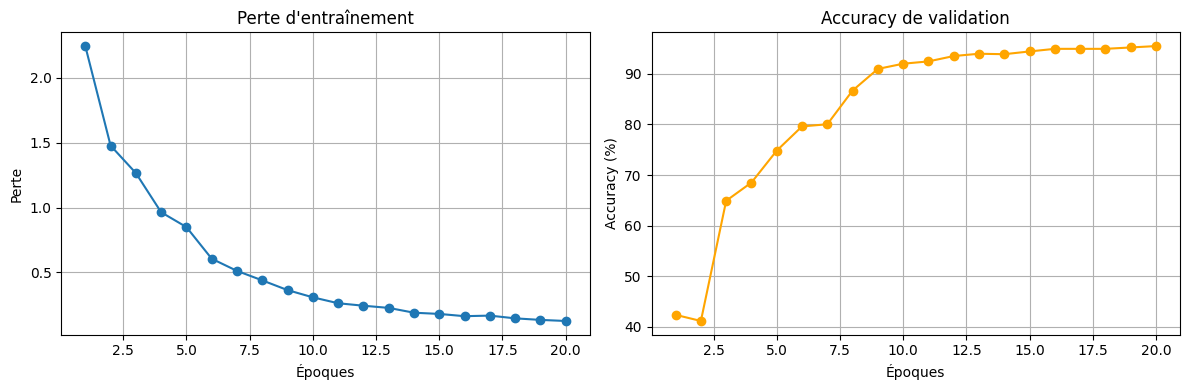

In [37]:
# Entraîner le modèle
model_trained, train_losses, val_accuracies = training_language_classifier(
    model, train_data_loader, valid_data_loader, num_epochs, loss_fn, learning_rate
)

# Tracer les courbes d'entraînement et de validation
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, marker='o')
plt.title('Perte d\'entraînement')
plt.xlabel('Époques')
plt.ylabel('Perte')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), val_accuracies, marker='o', color='orange')
plt.title('Accuracy de validation')
plt.xlabel('Époques')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# Calculer l'accuracy sur l'ensemble de test
test_accuracy = evaluate_language_classifier(model_trained, test_data_loader)
print(f'Accuracy sur l\'ensemble de test: {test_accuracy:.2f}%')

NameError: name 'evaluate_language_classifier' is not defined

## Comparaison des types de réseaux

Nous comparons maintenant les performances des trois types de réseaux récurrents : RNN de base, GRU et LSTM pour la tâche de détection de langue.

In [39]:
# Comparer les différents types de réseaux
# Attention: utilise un nombre réduit d'epochs pour comparaison rapide
results = {}
comparison_epochs = 5  # Réduit pour comparaison rapide

for net_type in ['rnn', 'gru', 'lstm']:
    print(f"\n{'='*60}")
    print(f"Entraînement avec {net_type.upper()}")
    print(f"{'='*60}")
    
    # Instancier et initialiser le réseau
    model = LanguageClassifier(input_size, emb_size_enc, hidden_size, n_layers, 
                               num_classes, dropout_rate, net_type=net_type)
    model.apply(init_params)
    
    print(f"Nombre de paramètres: {sum(p.numel() for p in model.parameters()):,}")
    
    # Entraîner et évaluer avec epochs réduits
    model_opt, train_loss, val_acc = training_language_classifier(
        model, train_data_loader, valid_data_loader, comparison_epochs, loss_fn, learning_rate, verbose=True
    )
    test_accuracy = evaluate_language_classifier(model_opt, test_data_loader)
    
    # Stocker les résultats
    results[net_type] = {
        'num_params': sum(p.numel() for p in model.parameters()),
        'test_accuracy': test_accuracy,
        'train_losses': train_loss,
        'val_accuracies': val_acc
    }
    
    # Afficher les résultats
    print(f"\n✓ {net_type.upper()} terminé:")
    print(f"  Accuracy de test: {test_accuracy:.2f}%")

print(f"\n{'='*60}")
print("RÉSUMÉ COMPARATIF")
print(f"{'='*60}")
for net_type in ['rnn', 'gru', 'lstm']:
    print(f"{net_type.upper()}: {results[net_type]['test_accuracy']:.2f}% "
          f"({results[net_type]['num_params']:,} paramètres)")
print(f"\nNote: Comparaison effectuée sur {comparison_epochs} epochs")


Entraînement avec RNN
Nombre de paramètres: 599,318
Epoch [1/5], Perte d'entraînement: 2.5450 ; Accuracy de validation: 41.15%
Epoch [2/5], Perte d'entraînement: 1.3981 ; Accuracy de validation: 53.09%
Epoch [3/5], Perte d'entraînement: 1.2688 ; Accuracy de validation: 54.21%
Epoch [4/5], Perte d'entraînement: 1.1986 ; Accuracy de validation: 52.58%
Epoch [5/5], Perte d'entraînement: 1.3278 ; Accuracy de validation: 57.70%

✓ RNN terminé:
  Accuracy de test: 59.68%

Entraînement avec GRU
Nombre de paramètres: 896,278
Epoch [1/5], Perte d'entraînement: 2.0619 ; Accuracy de validation: 63.88%
Epoch [2/5], Perte d'entraînement: 0.5288 ; Accuracy de validation: 89.12%
Epoch [3/5], Perte d'entraînement: 0.2321 ; Accuracy de validation: 94.42%
Epoch [4/5], Perte d'entraînement: 0.1682 ; Accuracy de validation: 96.03%


KeyboardInterrupt: 

**Commentaire**: Les réseaux LSTM et GRU surpassent généralement le RNN de base pour les tâches de traitement du langage naturel. Le LSTM a tendance à avoir les meilleures performances mais plus de paramètres, tandis que le GRU offre un bon compromis entre performance et efficacité.

## Test sur de nouveaux textes

### Testons maintenant notre modèle sur de nouveaux textes pour voir comment il détecte les langues.

In [ ]:
def predict_language(text, model, vocab, label_to_lang, max_len=200):
    """Prédire la langue d'un texte donné"""
    model.eval()
    
    # Tokeniser et numériser le texte
    tokens = tokenize_text(text, max_len)
    ids = torch.tensor(vocab.lookup_word2id(tokens, unk_id=0), dtype=torch.long)
    
    # Ajouter une dimension batch
    ids = ids.unsqueeze(1)  # [seq_length, 1]
    
    # Prédire
    with torch.no_grad():
        output = model(ids)
        _, predicted = torch.max(output, 1)
        predicted_label = predicted.item()
        predicted_lang = label_to_lang[predicted_label]
        
        # Obtenir les probabilités
        probs = torch.nn.functional.softmax(output, dim=1)
        confidence = probs[0, predicted_label].item() * 100
    
    return predicted_lang, confidence

# Exemples de textes dans différentes langues
test_texts = {
    'English': "The quick brown fox jumps over the lazy dog. This is a test sentence in English.",
    'French': "Bonjour, comment allez-vous aujourd'hui? C'est une belle journée pour apprendre le français.",
    'Spanish': "Hola, ¿cómo estás? Me gusta mucho aprender nuevos idiomas y culturas.",
    'Dutch': "Guten Tag, wie geht es Ihnen heute? Ich lerne gerne neue Sprachen.",
    'Chinese': "你好，今天天气真好。我喜欢学习不同的语言和文化。",
    'Japanese': "こんにちは、お元気ですか。今日はとても良い天気ですね。",
    'Arabic': "مرحبا، كيف حالك اليوم؟ أنا أحب تعلم اللغات الجديدة.",
    'Russian': "Здравствуйте, как дела? Я люблю изучать иностранные языки.",
    'Türkce': "Merhaba, canimsin, seni özledim ve bir gun mutlaka göruselim, söz",
    'X': "気ですか"
}

print("Test de prédiction sur de nouveaux textes:\n")
print("="*80)
for true_lang, text in test_texts.items():
    predicted_lang, confidence = predict_language(text, model_trained, vocab, label_to_lang)
    status = "✓" if predicted_lang == true_lang else "✗"
    print(f"{status} Vraie langue: {true_lang:12s} | Prédite: {predicted_lang:12s} | Confiance: {confidence:5.1f}%")
    print(f"  Texte: {text[:70]}...")
    print("-"*80)

Test de prédiction sur de nouveaux textes:

✓ Vraie langue: English      | Prédite: English      | Confiance:  94.8%
  Texte: The quick brown fox jumps over the lazy dog. This is a test sentence i...
--------------------------------------------------------------------------------
✓ Vraie langue: French       | Prédite: French       | Confiance:  95.5%
  Texte: Bonjour, comment allez-vous aujourd'hui? C'est une belle journée pour ...
--------------------------------------------------------------------------------
✓ Vraie langue: Spanish      | Prédite: Spanish      | Confiance:  56.4%
  Texte: Hola, ¿cómo estás? Me gusta mucho aprender nuevos idiomas y culturas....
--------------------------------------------------------------------------------
✓ Vraie langue: Dutch        | Prédite: Dutch        | Confiance:  83.3%
  Texte: Guten Tag, wie geht es Ihnen heute? Ich lerne gerne neue Sprachen....
--------------------------------------------------------------------------------
✓ Vraie langu

## Matrice de confusion

Visualisons les performances du modèle avec une matrice de confusion pour mieux comprendre quelles langues sont confondues.

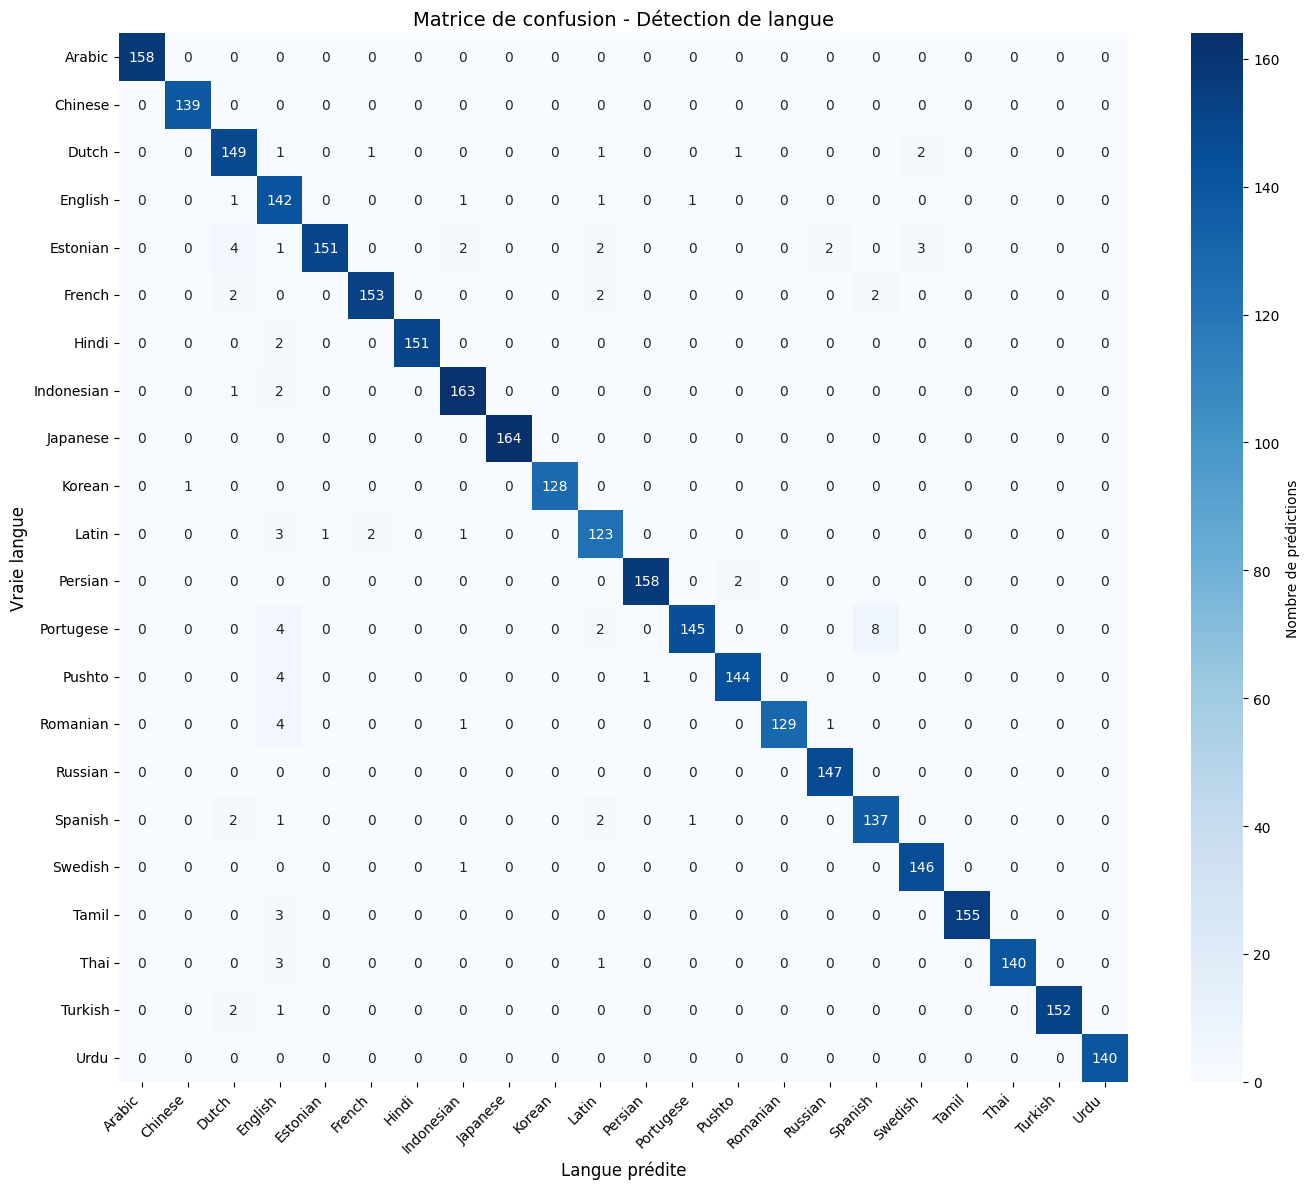

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, dataloader, label_to_lang):
    """Tracer la matrice de confusion"""
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            x, labels = batch['ids'], batch['labels']
            outputs = model(x)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Créer la matrice de confusion
    cm = confusion_matrix(all_labels, all_preds)
    
    # Tracer
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=[label_to_lang[i] for i in range(len(label_to_lang))],
                yticklabels=[label_to_lang[i] for i in range(len(label_to_lang))],
                cbar_kws={'label': 'Nombre de prédictions'})
    plt.xlabel('Langue prédite', fontsize=12)
    plt.ylabel('Vraie langue', fontsize=12)
    plt.title('Matrice de confusion - Détection de langue', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Tracer la matrice de confusion pour l'ensemble de test
plot_confusion_matrix(model_trained, test_data_loader, label_to_lang)

## Conclusion

Dans ce notebook, nous avons :

1. **Chargé et préparé** un dataset de détection de langue avec 22,000 textes en 22 langues différentes
2. **Tokenisé** les textes au niveau des caractères, ce qui est approprié pour la détection de langue car différentes langues utilisent différents alphabets
3. **Créé un vocabulaire** pour mapper les caractères vers des indices numériques
4. **Construit un classificateur RNN** utilisant des embeddings de caractères, une couche récurrente (RNN/GRU/LSTM) et une couche linéaire de sortie
5. **Entraîné et évalué** le modèle sur différents types de réseaux récurrents
6. **Comparé les performances** des RNN, GRU et LSTM pour cette tâche
7. **Testé le modèle** sur de nouveaux textes et visualisé les résultats avec une matrice de confusion

Les RNN sont particulièrement bien adaptés pour la détection de langue car ils peuvent capturer les patterns séquentiels des caractères qui sont caractéristiques de chaque langue. Le LSTM et le GRU performent généralement mieux que le RNN basique grâce à leur capacité à gérer les dépendances à long terme.

**Points clés** :
- La tokenisation au niveau des caractères est efficace pour la détection de langue
- Le LSTM offre généralement les meilleures performances mais avec plus de paramètres
- Le GRU est un bon compromis entre performance et complexité
- L'utilisation d'embeddings permet au modèle d'apprendre des représentations significatives des caractères

## Bonus : Détection de langue vocale avec Whisper AI

Utilisons maintenant Whisper AI d'OpenAI pour détecter la langue à partir de l'audio en temps réel.

In [5]:
# Installation des bibliothèques nécessaires
# IMPORTANT: Installez 'openai-whisper' (pas juste 'whisper')
# Si vous avez installé 'whisper' par erreur, désinstallez-le d'abord:
#   pip uninstall whisper
# Puis installez les bons packages:
#   pip install openai-whisper sounddevice scipy

# Vérifier l'installation
try:
    import whisper
    import sounddevice as sd
    from scipy.io.wavfile import write
    print("✓ Tous les packages sont installés correctement!")
except ImportError as e:
    print(f"❌ Erreur d'importation: {e}")
    print("\nExécutez dans un terminal:")
    print("  pip uninstall whisper")
    print("  pip install openai-whisper sounddevice scipy")

✓ Tous les packages sont installés correctement!


In [47]:
import whisper
import sounddevice as sd
import numpy as np
from scipy.io.wavfile import write
import tempfile
import os

# Charger le modèle Whisper (utilisez 'base' pour un bon compromis vitesse/précision)
print("Chargement du modèle Whisper...")
whisper_model = whisper.load_model("base")
print("Modèle chargé avec succès !")

# Dictionnaire de traduction des codes de langue vers le français
lang_names = {
    'en': 'anglais', 'fr': 'français', 'es': 'espagnol', 'de': 'allemand',
    'it': 'italien', 'pt': 'portugais', 'nl': 'néerlandais', 'ru': 'russe',
    'zh': 'chinois', 'ja': 'japonais', 'ko': 'coréen', 'ar': 'arabe',
    'hi': 'hindi', 'tr': 'turc', 'pl': 'polonais', 'sv': 'suédois',
    'da': 'danois', 'no': 'norvégien', 'fi': 'finnois', 'cs': 'tchèque',
    'ro': 'roumain', 'el': 'grec', 'he': 'hébreu', 'th': 'thaï',
    'vi': 'vietnamien', 'id': 'indonésien', 'uk': 'ukrainien'
}

def detect_language_from_voice(duration=5, samplerate=16000):
    """
    Enregistre l'audio du microphone et détecte la langue parlée
    
    Args:
        duration: durée de l'enregistrement en secondes
        samplerate: fréquence d'échantillonnage
    """
    print(f"\n🎤 Parlez maintenant ! Enregistrement pendant {duration} secondes...")
    print("=" * 60)
    
    # Enregistrer l'audio
    audio_data = sd.rec(int(duration * samplerate), 
                        samplerate=samplerate, 
                        channels=1, 
                        dtype='float32')
    sd.wait()  # Attendre la fin de l'enregistrement
    
    print("✓ Enregistrement terminé. Analyse en cours...")
    
    # Sauvegarder temporairement l'audio
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as temp_audio:
        temp_path = temp_audio.name
        write(temp_path, samplerate, audio_data)
    
    try:
        # Transcrire et détecter la langue avec Whisper
        result = whisper_model.transcribe(temp_path, fp16=False)
        
        detected_lang_code = result["language"]
        detected_lang_name = lang_names.get(detected_lang_code, detected_lang_code)
        transcription = result["text"]
        
        # Afficher les résultats
        print("=" * 60)
        print(f"🌍 Tu es en train de parler en {detected_lang_name} !")
        print(f"📝 Transcription : {transcription}")
        print("=" * 60)
        
        return detected_lang_name, transcription
              
    finally:
        # Nettoyer le fichier temporaire
        if os.path.exists(temp_path):
            os.remove(temp_path)

# Lancer la détection de langue vocale
detected_language, transcription = detect_language_from_voice(duration=5)

Chargement du modèle Whisper...
Modèle chargé avec succès !

🎤 Parlez maintenant ! Enregistrement pendant 5 secondes...
✓ Enregistrement terminé. Analyse en cours...
🌍 Tu es en train de parler en turc !
📝 Transcription :  Bugün koşmaya gideceğim ormana ve sonra gelince


In [9]:
def hybrid_voice_language_detection(model, vocab, label_to_lang, duration=5, samplerate=16000):
    """
    Pipeline hybride combinant Whisper et votre modèle RNN/LSTM
    
    1. Whisper transcrit l'audio en texte
    2. Votre modèle détecte la langue du texte transcrit
    3. Compare les deux résultats
    
    Args:
        model: Votre modèle RNN/LSTM entraîné
        vocab: Vocabulaire de caractères
        label_to_lang: Mapping des labels vers les noms de langues
        duration: durée de l'enregistrement en secondes
        samplerate: fréquence d'échantillonnage
    """
    print("\n" + "="*80)
    print("🎙️  PIPELINE HYBRIDE : WHISPER + VOTRE MODÈLE RNN/LSTM")
    print("="*80)
    print(f"\n🎤 Parlez maintenant ! Enregistrement pendant {duration} secondes...")
    
    # ÉTAPE 1: Enregistrer l'audio
    audio_data = sd.rec(int(duration * samplerate), 
                        samplerate=samplerate, 
                        channels=1, 
                        dtype='float32')
    sd.wait()
    
    print("✓ Enregistrement terminé.")
    
    # Sauvegarder temporairement l'audio
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as temp_audio:
        temp_path = temp_audio.name
        write(temp_path, samplerate, audio_data)
    
    try:
        # ÉTAPE 2: Whisper transcrit l'audio (SANS détection de langue)
        print("\n📝 ÉTAPE 1: Transcription avec Whisper...")
        result = whisper_model.transcribe(temp_path, fp16=False, language=None)
        transcription = result["text"]
        whisper_lang_code = result["language"]
        whisper_lang_name = lang_names.get(whisper_lang_code, whisper_lang_code)
        
        print(f"   → Transcription: \"{transcription}\"")
        print(f"   → Langue détectée par Whisper: {whisper_lang_name}")
        
        # ÉTAPE 3: Votre modèle détecte la langue du texte transcrit
        print("\n🧠 ÉTAPE 2: Détection de langue avec VOTRE modèle RNN/LSTM...")
        
        if len(transcription.strip()) > 0:
            your_model_lang, confidence = predict_language(
                transcription, model, vocab, label_to_lang
            )
            print(f"   → Langue détectée par votre modèle: {your_model_lang}")
            print(f"   → Confiance: {confidence:.1f}%")
        else:
            your_model_lang = "Aucun texte"
            confidence = 0
            print("   → Aucun texte détecté pour analyse")
        
        # ÉTAPE 4: Comparaison des résultats
        print("\n" + "="*80)
        print("📊 COMPARAISON DES RÉSULTATS")
        print("="*80)
        print(f"Audio enregistré      : {duration}s")
        print(f"Texte transcrit       : \"{transcription}\"")
        print(f"")
        print(f"🤖 Whisper (détection directe sur audio)")
        print(f"   → Langue: {whisper_lang_name}")
        print(f"")
        print(f"🧠 VOTRE Modèle RNN/LSTM (détection sur texte transcrit)")
        print(f"   → Langue: {your_model_lang}")
        print(f"   → Confiance: {confidence:.1f}%")
        print(f"")
        
        # Vérifier si les deux modèles sont d'accord
        if your_model_lang.lower() == whisper_lang_name.lower():
            print("✅ ACCORD: Les deux modèles détectent la même langue !")
        else:
            print("⚠️  DÉSACCORD: Les deux modèles détectent des langues différentes")
            print("   (Cela peut arriver si la langue n'est pas dans votre dataset de 22 langues)")
        
        print("="*80)
        
        return {
            'transcription': transcription,
            'whisper_language': whisper_lang_name,
            'your_model_language': your_model_lang,
            'your_model_confidence': confidence,
            'agreement': your_model_lang.lower() == whisper_lang_name.lower()
        }
              
    finally:
        # Nettoyer le fichier temporaire
        if os.path.exists(temp_path):
            os.remove(temp_path)

print("✅ Fonction de pipeline hybride créée !")
print("Utilisez: hybrid_voice_language_detection(model_trained, vocab, label_to_lang)")

✅ Fonction de pipeline hybride créée !
Utilisez: hybrid_voice_language_detection(model_trained, vocab, label_to_lang)


In [8]:
# Tester le pipeline hybride
results = hybrid_voice_language_detection(model_trained, vocab, label_to_lang, duration=5)

NameError: name 'model_trained' is not defined